In [55]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ucimachinelearning/photoplethysmography-ppg-dataset")

print("Path to dataset files:", path)

100%|██████████| 26.1M/26.1M [00:00<00:00, 41.7MB/s]

Extracting files...


Path to dataset files: /Users/ishananand/.cache/kagglehub/datasets/ucimachinelearning/photoplethysmography-ppg-dataset/versions/1


In [56]:
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import matplotlib.pyplot as plt

In [57]:
data = pd.read_csv("/Users/ishananand/Desktop/Time-Series/SignalProcessing/data/1/PPG_Dataset.csv")
data.head()

,0,1,2,3,4,5,6,7,8,9,...,1991,1992,1993,1994,1995,1996,1997,1998,1999,Label
0,-0.015552,0.016963,0.013575,0.027204,0.068154,0.129259,0.127915,0.345174,0.197811,0.167651,...,-0.426464,-0.346976,-0.132168,-0.252098,-0.241969,-0.134235,-0.091327,-0.081713,-0.057693,MI
1,0.002323,0.002754,0.022539,0.228807,0.107751,0.034439,0.086007,0.155667,0.163327,0.223759,...,-0.169345,-0.356808,-0.338996,-0.292489,-0.152872,-0.156076,-0.103265,-0.041579,-0.044272,MI
2,0.050481,-0.339781,0.265111,0.045092,0.040086,0.087173,0.092814,0.099586,-0.143305,0.164186,...,-0.401426,-0.402333,-0.373426,-0.303710,0.008599,-0.180633,-0.143135,-0.084758,0.060668,MI
3,0.023882,0.016561,0.248547,0.054567,0.128032,0.085954,0.107359,0.207137,0.174547,-0.100118,...,-0.390700,-0.353882,-0.294014,-0.267005,-0.242258,-0.186946,-0.173718,0.101331,0.063555,MI
4,-0.058591,0.171551,0.057262,0.270869,0.138357,0.078509,0.062504,0.104447,0.134795,0.194248,...,-0.391598,-0.334490,-0.326873,-0.249881,-0.210052,-0.194763,-0.415365,0.015432,0.010321,MI


In [58]:
data.shape

(2576, 2001)

In [59]:
signal_columns = data.columns.drop("Label")
samples = np.arange(len(signal_columns))
data["Label"].value_counts()


Label
MI        1294
Normal    1282
Name: count, dtype: int64

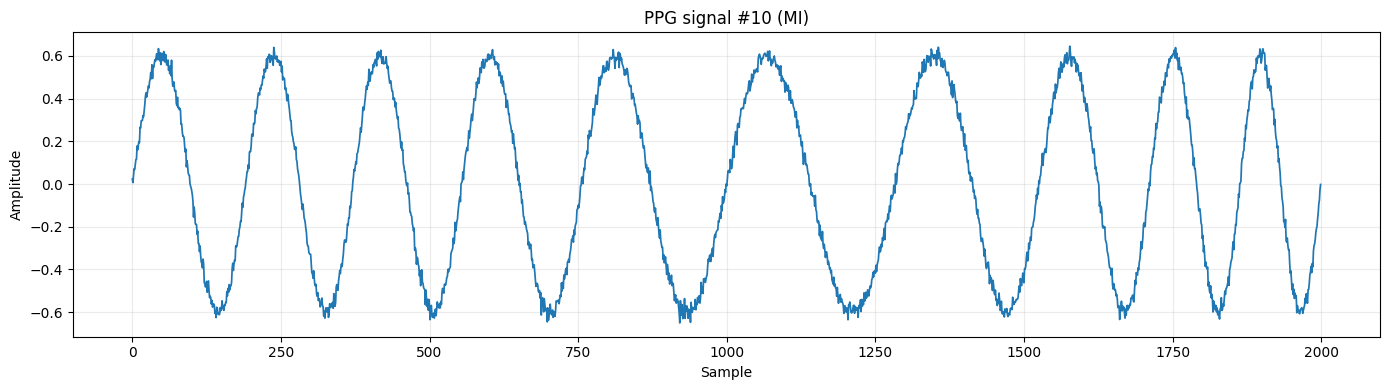

In [60]:
row_index = 10
signal = data.loc[row_index, signal_columns].astype(float).to_numpy()
label = data.loc[row_index, "Label"]

plt.figure(figsize=(14, 4))
plt.plot(samples, signal, linewidth=1.25)
plt.title(f"PPG signal #{row_index} ({label})")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [61]:
data.isna().sum()

0        0
1        0
2        0
3        0
4        0
        ..
1996     0
1997     0
1998     0
1999     0
Label    0
Length: 2001, dtype: int64

## Modeling pipeline
Run these cells in order after loading `data`. The workflow is: split, normalize, filter, baseline models, feature models, 1D CNN, then pretrained AlexNet and Inception v3.


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.stats import skew, kurtosis

from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

try:
    from torchvision.models import alexnet, AlexNet_Weights, inception_v3, Inception_V3_Weights, resnet18, ResNet18_Weights
except Exception as exc:
    print("TorchVision import failed. Install torchvision before running transfer learning cells.")
    print(exc)


In [63]:
X = data.drop(columns=["Label"]).astype("float32")
y = data["Label"].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42,
)

def row_zscore(frame):
    row_mean = frame.mean(axis=1)
    row_std = frame.std(axis=1).replace(0, 1)
    return frame.sub(row_mean, axis=0).div(row_std, axis=0).astype("float32")

X_train_norm = row_zscore(X_train)
X_val_norm = row_zscore(X_val)
X_test_norm = row_zscore(X_test)

print(X_train_norm.shape, X_val_norm.shape, X_test_norm.shape)


{'MI': np.int64(0), 'Normal': np.int64(1)}
(1648, 2000) (412, 2000) (516, 2000)


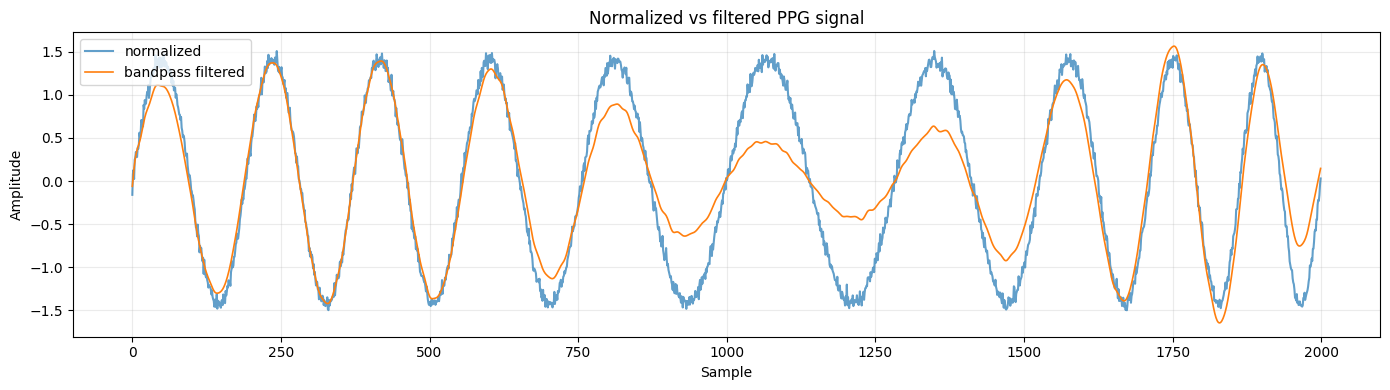

In [64]:
FS = 125
LOWCUT = 0.5
HIGHCUT = 8.0


def bandpass_filter(signal, fs=FS, lowcut=LOWCUT, highcut=HIGHCUT, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal).astype("float32")


def filter_frame(frame):
    filtered = np.vstack([bandpass_filter(row) for row in frame.to_numpy(dtype="float32")])
    return pd.DataFrame(filtered, index=frame.index, columns=frame.columns)

X_train_filt = filter_frame(X_train_norm)
X_val_filt = filter_frame(X_val_norm)
X_test_filt = filter_frame(X_test_norm)

plt.figure(figsize=(14, 4))
plt.plot(X_train_norm.iloc[0].to_numpy(), label="normalized", alpha=0.7)
plt.plot(X_train_filt.iloc[0].to_numpy(), label="bandpass filtered", linewidth=1.2)
plt.title("Normalized vs filtered PPG signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [65]:
def evaluate_sklearn_model(name, model, X_fit, y_fit, X_eval, y_eval):
    model.fit(X_fit, y_fit)
    pred = model.predict(X_eval)
    print(f"\n{name}")
    print(classification_report(y_eval, pred, target_names=label_encoder.classes_))
    print(confusion_matrix(y_eval, pred))
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_eval)[:, 1]
        print("ROC-AUC:", roc_auc_score(y_eval, scores))
    return model

logreg = evaluate_sklearn_model(
    "Logistic Regression on filtered signals",
    LogisticRegression(max_iter=3000, class_weight="balanced"),
    X_train_filt,
    y_train,
    X_test_filt,
    y_test,
)

rf_raw = evaluate_sklearn_model(
    "Random Forest on filtered signals",
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    X_train_filt,
    y_train,
    X_test_filt,
    y_test,
)

svm = evaluate_sklearn_model(
    "RBF SVM on filtered signals",
    SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced", probability=True),
    X_train_filt,
    y_train,
    X_test_filt,
    y_test,
)



Logistic Regression on filtered signals
              precision    recall  f1-score   support

          MI       0.96      0.93      0.95       259
      Normal       0.94      0.96      0.95       257

    accuracy                           0.95       516
   macro avg       0.95      0.95      0.95       516
weighted avg       0.95      0.95      0.95       516

[[242  17]
 [ 10 247]]
ROC-AUC: 0.9453450114928714

Random Forest on filtered signals
              precision    recall  f1-score   support

          MI       0.96      0.93      0.95       259
      Normal       0.94      0.96      0.95       257

    accuracy                           0.95       516
   macro avg       0.95      0.95      0.95       516
weighted avg       0.95      0.95      0.95       516

[[242  17]
 [ 10 247]]
ROC-AUC: 0.9489055481273381

RBF SVM on filtered signals
              precision    recall  f1-score   support

          MI       0.96      0.93      0.95       259
      Normal       0.94      0

## Handcrafted features
These features summarize amplitude, morphology, frequency content, and rough pulse behavior.


In [66]:
def spectral_entropy(power):
    power = np.asarray(power, dtype="float64")
    total = power.sum()
    if total <= 0:
        return 0.0
    prob = power / total
    prob = prob[prob > 0]
    return float(-(prob * np.log2(prob)).sum())


def extract_ppg_features(signal, fs=FS):
    signal = np.asarray(signal, dtype="float32")
    peaks, properties = find_peaks(signal, distance=max(1, int(0.3 * fs)), prominence=0.1)
    freqs, power = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    dominant_idx = int(np.argmax(power))
    peak_distances = np.diff(peaks) / fs if len(peaks) > 1 else np.array([])
    peak_values = signal[peaks] if len(peaks) else np.array([])

    return {
        "mean": float(np.mean(signal)),
        "std": float(np.std(signal)),
        "min": float(np.min(signal)),
        "max": float(np.max(signal)),
        "range": float(np.ptp(signal)),
        "rms": float(np.sqrt(np.mean(signal ** 2))),
        "skew": float(skew(signal)),
        "kurtosis": float(kurtosis(signal)),
        "energy": float(np.sum(signal ** 2)),
        "num_peaks": int(len(peaks)),
        "mean_peak_height": float(np.mean(peak_values)) if len(peak_values) else 0.0,
        "std_peak_height": float(np.std(peak_values)) if len(peak_values) else 0.0,
        "mean_peak_distance_sec": float(np.mean(peak_distances)) if len(peak_distances) else 0.0,
        "std_peak_distance_sec": float(np.std(peak_distances)) if len(peak_distances) else 0.0,
        "dominant_frequency": float(freqs[dominant_idx]),
        "dominant_power": float(power[dominant_idx]),
        "spectral_entropy": spectral_entropy(power),
        "low_band_power": float(power[(freqs >= 0.5) & (freqs < 2.0)].sum()),
        "mid_band_power": float(power[(freqs >= 2.0) & (freqs < 5.0)].sum()),
        "high_band_power": float(power[(freqs >= 5.0) & (freqs <= 8.0)].sum()),
    }


def make_feature_frame(frame):
    features = [extract_ppg_features(row) for row in frame.to_numpy(dtype="float32")]
    return pd.DataFrame(features, index=frame.index).replace([np.inf, -np.inf], np.nan).fillna(0)

train_features = make_feature_frame(X_train_filt)
val_features = make_feature_frame(X_val_filt)
test_features = make_feature_frame(X_test_filt)

train_features.head()


,mean,std,min,max,range,rms,skew,kurtosis,energy,num_peaks,mean_peak_height,std_peak_height,mean_peak_distance_sec,std_peak_distance_sec,dominant_frequency,dominant_power,spectral_entropy,low_band_power,mid_band_power,high_band_power
651,0.013381,0.787884,-1.644940,1.563149,3.208089,0.787998,-0.040014,-0.953302,1241.881348,10,1.124224,0.338326,1.652444,0.306611,0.488281,0.839915,1.401760,0.501878,0.000227,0.000149
703,0.012476,0.784681,-1.629486,1.540624,3.170110,0.784780,-0.042499,-0.955697,1231.760742,10,1.116789,0.334373,1.643556,0.314217,0.488281,0.833465,1.401035,0.498858,0.000280,0.000137
969,0.005431,0.704658,-1.617561,1.561325,3.178886,0.704679,-0.036949,-0.402087,993.144226,17,0.796632,0.595761,0.950500,0.406450,0.976562,0.466215,1.861786,0.650938,0.003932,0.003145
1283,0.011500,0.783799,-1.659065,1.554459,3.213525,0.783884,-0.036651,-0.941405,1228.947266,10,1.116249,0.338645,1.647111,0.326587,0.488281,0.831753,1.400664,0.499101,0.000258,0.000120
652,0.012211,0.783998,-1.635362,1.566174,3.201535,0.784093,-0.033965,-0.948416,1229.603638,10,1.125517,0.335289,1.647111,0.305271,0.488281,0.832979,1.401419,0.500150,0.000227,0.000150



Random Forest on handcrafted features
              precision    recall  f1-score   support

          MI       0.96      0.93      0.95       259
      Normal       0.94      0.96      0.95       257

    accuracy                           0.95       516
   macro avg       0.95      0.95      0.95       516
weighted avg       0.95      0.95      0.95       516

[[242  17]
 [ 10 247]]
ROC-AUC: 0.9530895542568695


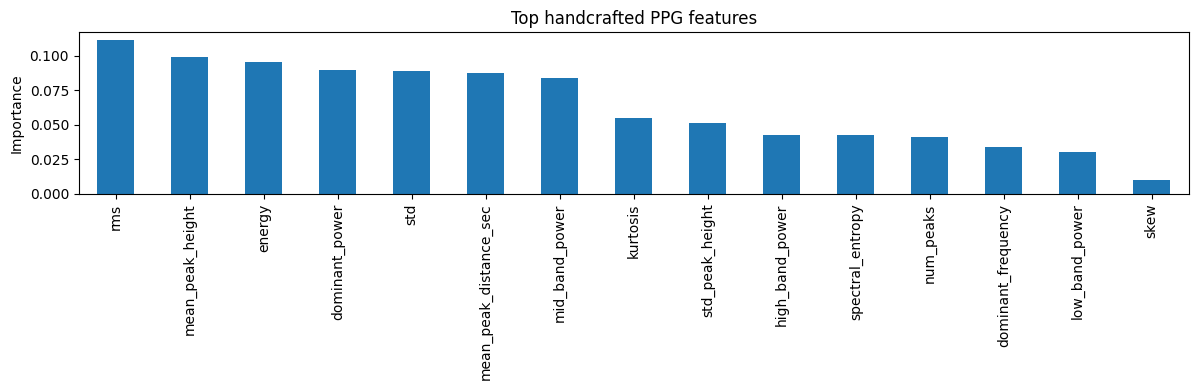

In [67]:
rf_features = evaluate_sklearn_model(
    "Random Forest on handcrafted features",
    RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42, n_jobs=-1),
    train_features,
    y_train,
    test_features,
    y_test,
)

feature_importance = pd.Series(rf_features.feature_importances_, index=train_features.columns)
feature_importance.sort_values(ascending=False).head(15).plot(kind="bar", figsize=(12, 4))
plt.title("Top handcrafted PPG features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## 1D CNN
This model learns directly from the filtered waveform.


In [68]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(device)

class PPGDataset(Dataset):
    def __init__(self, X_frame, y_array):
        self.X = torch.tensor(X_frame.to_numpy(dtype="float32"), dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y_array, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(PPGDataset(X_train_filt, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(PPGDataset(X_val_filt, y_val), batch_size=batch_size)
test_loader = DataLoader(PPGDataset(X_test_filt, y_test), batch_size=batch_size)


mps


In [69]:
class PPG1DCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=9, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_torch_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            if hasattr(logits, "logits"):
                logits = logits.logits
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                if hasattr(logits, "logits"):
                    logits = logits.logits
                pred = logits.argmax(dim=1)
                correct += (pred == yb).sum().item()
                total += yb.numel()

        print(f"epoch {epoch:02d} | train loss {train_loss / len(train_loader.dataset):.4f} | val acc {correct / total:.4f}")

    return model


def evaluate_torch_model(model, loader):
    model.eval()
    preds = []
    probs = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            if hasattr(logits, "logits"):
                logits = logits.logits
            prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            pred = logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred)
            probs.extend(prob)
            targets.extend(yb.numpy())

    print(classification_report(targets, preds, target_names=label_encoder.classes_))
    print(confusion_matrix(targets, preds))
    print("ROC-AUC:", roc_auc_score(targets, probs))


In [70]:
cnn_1d = PPG1DCNN(num_classes=len(label_encoder.classes_))
cnn_1d = train_torch_model(cnn_1d, train_loader, val_loader, epochs=10, lr=1e-3)
evaluate_torch_model(cnn_1d, test_loader)


epoch 01 | train loss 0.2544 | val acc 0.4976
epoch 02 | train loss 0.1458 | val acc 0.4976
epoch 03 | train loss 0.1461 | val acc 0.9660
epoch 04 | train loss 0.1405 | val acc 0.9684
epoch 05 | train loss 0.1451 | val acc 0.9684
epoch 06 | train loss 0.1410 | val acc 0.9684
epoch 07 | train loss 0.1470 | val acc 0.5024
epoch 08 | train loss 0.1474 | val acc 0.9684
epoch 09 | train loss 0.1482 | val acc 0.9684
epoch 10 | train loss 0.1434 | val acc 0.9684
              precision    recall  f1-score   support

          MI       0.96      0.93      0.95       259
      Normal       0.94      0.96      0.95       257

    accuracy                           0.95       516
   macro avg       0.95      0.95      0.95       516
weighted avg       0.95      0.95      0.95       516

[[242  17]
 [ 10 247]]
ROC-AUC: 0.9466896023316256


## Transfer learning with AlexNet and Inception v3 and ResNet
These pretrained image models need 2D, 3-channel inputs, so each 1D PPG waveform is resized into a simple signal image tensor. This is a practical transfer-learning experiment, but the 1D CNN is usually the more natural model for this dataset.


In [71]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class PPGImageDataset(Dataset):
    def __init__(self, X_frame, y_array, image_size):
        self.X = torch.tensor(X_frame.to_numpy(dtype="float32"), dtype=torch.float32)
        self.y = torch.tensor(y_array, dtype=torch.long)
        self.image_size = image_size

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        signal = self.X[idx]
        signal = (signal - signal.mean()) / (signal.std() + 1e-6)
        signal = signal.view(1, 1, -1)
        signal = F.interpolate(signal, size=self.image_size, mode="linear", align_corners=False).squeeze(0)
        image = signal.repeat(3, self.image_size, 1)
        image = (image - image.min()) / (image.max() - image.min() + 1e-6)
        image = (image - IMAGENET_MEAN) / IMAGENET_STD
        return image, self.y[idx]


def make_image_loaders(image_size, batch_size=24):
    train = DataLoader(PPGImageDataset(X_train_filt, y_train, image_size), batch_size=batch_size, shuffle=True)
    val = DataLoader(PPGImageDataset(X_val_filt, y_val, image_size), batch_size=batch_size)
    test = DataLoader(PPGImageDataset(X_test_filt, y_test, image_size), batch_size=batch_size)
    return train, val, test


In [72]:
alex_train_loader, alex_val_loader, alex_test_loader = make_image_loaders(image_size=224, batch_size=24)

alex_weights = AlexNet_Weights.DEFAULT
alex_model = alexnet(weights=alex_weights)
for param in alex_model.features.parameters():
    param.requires_grad = False

alex_model.classifier[6] = nn.Linear(alex_model.classifier[6].in_features, len(label_encoder.classes_))

alex_model = train_torch_model(alex_model, alex_train_loader, alex_val_loader, epochs=5, lr=1e-4)
evaluate_torch_model(alex_model, alex_test_loader)


epoch 01 | train loss 0.2002 | val acc 0.9684
epoch 02 | train loss 0.1607 | val acc 0.9684
epoch 03 | train loss 0.1543 | val acc 0.9684
epoch 04 | train loss 0.1594 | val acc 0.9684
epoch 05 | train loss 0.1549 | val acc 0.9684
              precision    recall  f1-score   support

          MI       0.96      0.93      0.95       259
      Normal       0.94      0.96      0.95       257

    accuracy                           0.95       516
   macro avg       0.95      0.95      0.95       516
weighted avg       0.95      0.95      0.95       516

[[242  17]
 [ 10 247]]
ROC-AUC: 0.9591965506362393


In [73]:
inception_train_loader, inception_val_loader, inception_test_loader = make_image_loaders(image_size=299, batch_size=12)

inception_weights = Inception_V3_Weights.DEFAULT
inception_model = inception_v3(weights=inception_weights, aux_logits=True)
for param in inception_model.parameters():
    param.requires_grad = False

inception_model.fc = nn.Linear(inception_model.fc.in_features, len(label_encoder.classes_))
for param in inception_model.fc.parameters():
    param.requires_grad = True

if inception_model.AuxLogits is not None:
    inception_model.AuxLogits.fc = nn.Linear(inception_model.AuxLogits.fc.in_features, len(label_encoder.classes_))
    for param in inception_model.AuxLogits.fc.parameters():
        param.requires_grad = True

inception_model = train_torch_model(inception_model, inception_train_loader, inception_val_loader, epochs=5, lr=1e-4)
evaluate_torch_model(inception_model, inception_test_loader)


epoch 01 | train loss 0.5678 | val acc 0.9587
epoch 02 | train loss 0.3887 | val acc 0.9636
epoch 03 | train loss 0.3196 | val acc 0.9636
epoch 04 | train loss 0.2953 | val acc 0.9660
epoch 05 | train loss 0.2649 | val acc 0.9684
              precision    recall  f1-score   support

          MI       0.96      0.93      0.95       259
      Normal       0.94      0.96      0.95       257

    accuracy                           0.95       516
   macro avg       0.95      0.95      0.95       516
weighted avg       0.95      0.95      0.95       516

[[242  17]
 [ 10 247]]
ROC-AUC: 0.9478539128344576


In [74]:
resnet_train_loader, resnet_val_loader, resnet_test_loader = make_image_loaders(image_size=224, batch_size=24)

resnet_weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=resnet_weights)
for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, len(label_encoder.classes_))
for param in resnet_model.fc.parameters():
    param.requires_grad = True

resnet_model = train_torch_model(resnet_model, resnet_train_loader, resnet_val_loader, epochs=5, lr=1e-4)
evaluate_torch_model(resnet_model, resnet_test_loader)


epoch 01 | train loss 0.5278 | val acc 0.8180
epoch 02 | train loss 0.2891 | val acc 0.9684
epoch 03 | train loss 0.2157 | val acc 0.9684
epoch 04 | train loss 0.1885 | val acc 0.9684
epoch 05 | train loss 0.1681 | val acc 0.9684
              precision    recall  f1-score   support

          MI       0.96      0.93      0.95       259
      Normal       0.94      0.96      0.95       257

    accuracy                           0.95       516
   macro avg       0.95      0.95      0.95       516
weighted avg       0.95      0.95      0.95       516

[[242  17]
 [ 10 247]]
ROC-AUC: 0.9414239141865601


## What to compare
Use the test-set F1-score, recall for the MI class, ROC-AUC, and confusion matrix. If the pretrained image models underperform the 1D CNN, that is expected: AlexNet, ResNet, and Inception v3 were pretrained on natural images, while PPG is a 1D biomedical signal.
